**Neural Network From Scratch**

In [1]:
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
nn_architecture = [
    {"input_dim": 2, "output_dim": 4, "activation": "relu"},
    {"input_dim": 4, "output_dim": 6, "activation": "relu"},
    {"input_dim": 6, "output_dim": 6, "activation": "relu"},
    {"input_dim": 6, "output_dim": 4, "activation": "relu"},
    {"input_dim": 4, "output_dim": 1, "activation": "sigmoid"},
]

In [3]:
def init_layers(nn_architecture, seed=99):
    np.random.seed(seed)
    params_values = {}

    for idx, layer in enumerate(nn_architecture):
        layer_idx = idx + 1
        params_values['W' + str(layer_idx)] = np.random.randn(
            layer["output_dim"], layer["input_dim"]) * 0.1

        params_values['b' + str(layer_idx)] = np.zeros((layer["output_dim"], 1))

    return params_values

In [4]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def sigmoid_backward(dA, x):
    sig = sigmoid(x)
    return dA * sig * (1-sig)

def relu_backward(dA, Z):
    """ ReLU backward propagation """
    dZ = np.array(dA, copy=True)
    dZ[Z <= 0] = 0
    return dZ

In [5]:
def convert_prob_into_class(probs):
    """
    Converts probabilities into binary classes (0 or 1).
    """
    # Use 0.5 as the threshold for sigmoid outputs
    return (probs > 0.5).astype(int)

In [6]:
def single_layer_forward_propagation(A_prev, W_curr, b_curr, activation="relu"):
    # Step 1: Linear Transformation
    Z_curr = np.dot(W_curr, A_prev) + b_curr

    # Step 2: Selection of Activation Function
    if activation == "relu":
        activation_func = relu
    elif activation == "sigmoid":
        activation_func = sigmoid
    else:
        raise Exception("Non-supported activation function")

    # Step 3: Return both the activation (A) and the linear cache (Z)
    # The cache (Z) is crucial for backpropagation later!
    return activation_func(Z_curr), Z_curr

In [7]:
def get_cost_value(Y_hat, Y):
    # m is the number of examples
    m = Y_hat.shape[1]

    # Standard Cross-Entropy formula:
    # -1/m * (Y * log(Y_hat) + (1-Y) * log(1-Y_hat))
    cost = -1/m * (np.dot(Y, np.log(Y_hat).T) + np.dot(1 - Y, np.log(1 - Y_hat).T))

    # np.squeeze removes redundant dimensions (e.g., [[0.5]] becomes 0.5)
    return np.squeeze(cost)

In [8]:
def get_accuracy_value(Y_hat, Y):
    # Convert probabilities (0.0 to 1.0) into classes (0 or 1)
    Y_hat_class = convert_prob_into_class(Y_hat)

    # Compare predictions to actual labels and take the average
    return (Y_hat_class == Y).mean()

In [9]:
def single_layer_backward_propagation(dA_curr, Z_curr, W_curr, b_curr, A_prev, activation="relu"):
    m = A_prev.shape[1]

    if activation == "relu":
        dZ_curr = relu_backward(dA_curr, Z_curr)
    elif activation == "sigmoid":
        dZ_curr = sigmoid_backward(dA_curr, Z_curr)
    else:
        raise Exception('Non-supported activation function')

    dW_curr = np.dot(dZ_curr, A_prev.T) / m
    db_curr = np.sum(dZ_curr, axis=1, keepdims=True) / m
    dA_prev = np.dot(W_curr.T, dZ_curr)

    return dA_prev, dW_curr, db_curr

In [10]:
def full_backward_propagation(Y_hat, Y, memory, params_values, nn_architecture, X):
    grads_values = {}
    m = Y.shape[1]
    Y = Y.reshape(Y_hat.shape)

    # Initial derivative from cost
    dA_prev = - (np.divide(Y, Y_hat) - np.divide(1 - Y, 1 - Y_hat))

    for layer_idx_prev, layer in reversed(list(enumerate(nn_architecture))):
        layer_idx_curr = layer_idx_prev + 1

        # Get cached values
        Z_curr = memory["Z" + str(layer_idx_curr)]
        A_curr = memory["A" + str(layer_idx_curr)]

        # For the first layer, A_prev is input X
        if layer_idx_prev == 0:
            A_prev = X
        else:
            A_prev = memory["A" + str(layer_idx_prev)]

        dA_prev, dW_curr, db_curr = single_layer_backward_propagation(
            dA_prev, Z_curr,
            params_values["W" + str(layer_idx_curr)],
            params_values["b" + str(layer_idx_curr)],
            A_prev,
            layer["activation"]
        )

        grads_values["dW" + str(layer_idx_curr)] = dW_curr
        grads_values["db" + str(layer_idx_curr)] = db_curr

    return grads_values

In [11]:
# ====================== FULL FORWARD PROPAGATION ======================
def full_forward_propagation(X, params_values, nn_architecture):
    """
    Implements forward propagation for the entire network.
    """
    memory = {}   # To store cache for backpropagation
    A_prev = X

    for idx, layer in enumerate(nn_architecture):
        layer_idx = idx + 1
        A_curr, Z_curr = single_layer_forward_propagation(
            A_prev,
            params_values["W" + str(layer_idx)],
            params_values["b" + str(layer_idx)],
            layer["activation"]
        )

        # Save cache
        memory["A" + str(layer_idx)] = A_curr
        memory["Z" + str(layer_idx)] = Z_curr

        A_prev = A_curr

    return A_curr, memory   # A_curr is the final output (Y_hat)

In [12]:
def update(params_values, grads_values, nn_architecture, learning_rate):
    """
    Updates parameters using gradient descent
    """
    for layer_idx, layer in enumerate(nn_architecture, 1):
        params_values["W" + str(layer_idx)] -= learning_rate * grads_values["dW" + str(layer_idx)]
        params_values["b" + str(layer_idx)] -= learning_rate * grads_values["db" + str(layer_idx)]

    return params_values

Iteration: 0 - cost: 0.69316 - accuracy: 0.50000
Iteration: 1000 - cost: 0.69311 - accuracy: 0.79125
Iteration: 2000 - cost: 0.69310 - accuracy: 0.86125
Iteration: 3000 - cost: 0.69309 - accuracy: 0.85750
Iteration: 4000 - cost: 0.69308 - accuracy: 0.85500
Iteration: 5000 - cost: 0.69307 - accuracy: 0.85250
Iteration: 6000 - cost: 0.69306 - accuracy: 0.85125
Iteration: 7000 - cost: 0.69305 - accuracy: 0.84625
Iteration: 8000 - cost: 0.69303 - accuracy: 0.84000
Iteration: 9000 - cost: 0.69300 - accuracy: 0.83500


Text(0.5, 0, 'Epochs')

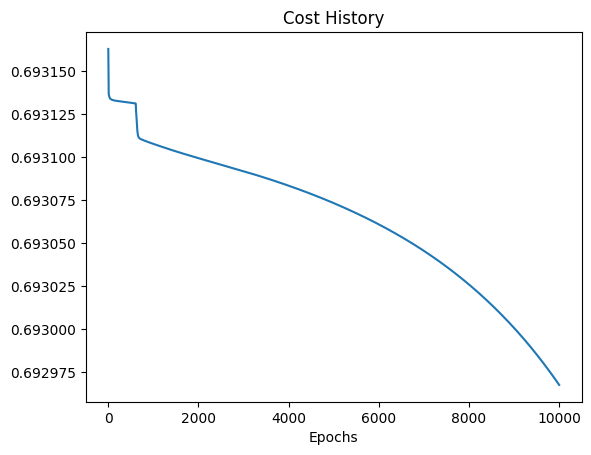

In [13]:
def train(X, Y, nn_architecture, epochs, learning_rate):
    params_values = init_layers(nn_architecture, 2)
    cost_history = []
    accuracy_history = []

    for i in range(epochs):
        Y_hat, memory = full_forward_propagation(X, params_values, nn_architecture)
        cost = get_cost_value(Y_hat, Y)
        cost_history.append(cost)
        accuracy = get_accuracy_value(Y_hat, Y)
        accuracy_history.append(accuracy)

        grads_values = full_backward_propagation(Y_hat, Y, memory, params_values, nn_architecture, X)
        params_values = update(params_values, grads_values, nn_architecture, learning_rate)

        if i % 1000 == 0:
            print(f"Iteration: {i} - cost: {cost:.5f} - accuracy: {accuracy:.5f}")

    return params_values, cost_history, accuracy_history

# Generate data
X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Transpose for the NN (Features x Samples)
X_train_T = X_train.T
y_train_T = y_train.reshape(1, -1)

# Train
params, cost_h, acc_h = train(X_train_T, y_train_T, nn_architecture, 10000, 0.01)

plt.plot(cost_h)
plt.title("Cost History")
plt.xlabel("Epochs")